# VOS calibration of $\mathbb{Z}_N$ wall networks — physical vs PRS (stages 1 + 2)

**Session 2026-07-03 · beyond-PRS programme · companion doc: `beyond_prs_ZN_framework_notes.md` (esp. §9) · VOS spec: `analysis/vos_zn_section.tex` + talk slide "Generalised VOS".**

⚠️ **This notebook is GENERATED** by `analysis/build_vos_calibration_nb.py`. Edit the *builder*, then:
`python3 build_vos_calibration_nb.py && jupyter nbconvert --to notebook --execute --inplace VOS_calibration.ipynb`

---

## READ THIS FIRST — what this notebook does and what it found

**What it does.** Fits the generalised $\mathbb{Z}_N$ VOS ODEs (full time-dependent trajectories, *not* just the fixed-point inversion used previously) to the $N{=}1024$ greedy lattice data — wall area $\mathcal{A}(\eta)$, wall velocity $v(\eta)$, junction-string length $\xi(\eta)$ — separately for **physical** and **PRS** evolution, per model (Z₃/Z₄) and per $\beta_N \in \{0.01, 0.1, 0.3, 0.7, 0.9\}$, 3 seeds each.

**Theory inputs being tested** (derived 2026-07-03, notes §9; all at Sousa–Avelino rigor):
- **D1 (walls):** planar-wall momentum law $\hat\gamma\hat v \propto (AC)^{-1/2}$ ⇒ the VOS wall damping $3Hv$ is **identical** for physical $(a^2,a^2,a^4)$ and PRS $(a^3,a^3,a^3)$ — the 2ℋ-vs-3ℋ EOM friction difference is compensated by comoving-tension growth for walls (NOT for junctions or radiation).
- **F₂ (junction strings):** $\hat\gamma\hat v \propto (AB)^{-1/2}$ ⇒ damping index $n{=}2$ physical, $n{=}3$ PRS — junction strings over-damped by exactly one power of $a$ in ANY width-fixed wall-exact scheme (universal). In VOS language: junction importance / friction boosted $\propto a$ under PRS.

**Findings (numbers = 2026-07-03 execution; rerun to refresh):**
1. **$\alpha_J^{\rm phys}(\beta)$ extracted** (paper-1 deliverable): Z₃ = {0.1: 1.48, 0.3: 2.17, 0.7: 0.60, 0.9: 0.25} — **non-monotonic, peaks near $\beta_\star$**, contradicting the saturating ansatz in `vos_zn_section.tex`; Z₄ (≤ $\beta_\star$) = {0.42, 0.97, 0.72}.
2. **PRS wall fits demand α_J 4–7× larger** or rail at the bound (fitter kills chopping entirely to reproduce the PRS $\mathcal{A}$-creep) — sign-consistent with the derived junction boost, **but wall observables cannot measure the drift exponent** ($p$ in $\alpha_J \propto a^p$): static/drift/freeP tie in χ² (structural degeneracy, see §"Fitting machinery").
3. **Velocity dressing law (headline):** $\mathcal{A}$ fits BOTH evolutions with tiny residuals; the misfit is concentrated in $v$, and it is a clean scale-factor power: $v_{\rm data}/v_{\rm VOS} \propto a^{\hat q}$ with $\hat q_{\rm phys} \approx 0.08$–$0.13 \pm 0.1$ (≈ 0) and $\hat q_{\rm PRS} \approx 0.12$–$0.23 \pm 0.04$ (**nonzero, β-stable, both models**; 0.50 at β=0.01). ⇒ *Prescription: PRS velocities need ÷$a^{\hat q}$ on top of the established ×$a^2$ weight fix to be quoted as physical.* Deriving $\hat q$ is an open theory target (corrugations / radiation back-reaction, notes D5).
4. **The ξ damping-index test (n=2 vs 3) is NOT identifiable from ξ(η) trajectories alone** — the joint fits are over-flexible (see stage 2b). Paths: junction-velocity proxy (velA06) or the boosted-junction rig (decisive).
5. **Z₄ above $\beta_\star$** (input DP: junctions persist above $\beta_\star$; only the opposite→adjacent decay channel $e(\beta)$ dies, α_J must stay): two-species fits (shared α_J, $e{=}0$, $\mathcal{A}_2$ fitted, velBnon dropped as junk) → **PRS fits fine (χ² ≈ 0.6–1.1) but PHYSICAL misfits badly (χ² ≈ 21–23, α_J→0)** ⇒ the shared-$d_N$ two-species ansatz is inadequate for the physical Z₄ network above $\beta_\star$. Warning: a PRS-only calibration would have looked fine.

---

## The VOS model being fitted

Single species $i$ (radiation domination, physical/cosmic time $t$, $H = 1/2t$):

$$\dot\ell_i = (1+3v_i^2)\,H\ell_i + c_w v_i + d_N\,[k_0 - k_w(v_i)]^{r}, \qquad
\dot v_i = (1-v_i^2)\left[\frac{k_w(v_i)}{\ell_i} - 3Hv_i\right]$$

$$k_w(v) = k_0\,\frac{1-(qv^2)^b}{1+(qv^2)^b}, \qquad
d_N = \frac{2\,d_2}{N}\,\frac{1}{1+\alpha_J\,(N-2)}, \qquad \mathcal{A}_i = \frac{1}{2H\ell_i} = \frac{t}{\ell_i}.$$

Z₂-calibrated constants $c_w{=}0,\ d_2{=}0.26,\ r{=}1.42,\ q{=}3.35,\ b{=}1.08,\ k_0{=}1.77$ are **held fixed** — only $\alpha_J$ (and its drift exponent $p$) carries the scheme- and $\beta$-dependence. Variants:
`static`: $\alpha_J$ const · `drift`: $\alpha_J = \alpha_{J0}(a/a_{\rm ref})$ (the derived PRS boost) · `freeP`: $\alpha_J = \alpha_{J0}(a/a_{\rm ref})^p$, $p$ free. Prediction: $\hat p \approx 0$ (phys), $\approx 1$ (PRS).

**Species handling (Z₄):** below $\beta_\star{=}1/3$ opposite walls split into adjacent pairs → single adjacent species (the $\mathcal{A}_2$/velBnon diagnostics measure under-resolved antipodal *sites*, not walls — vacuous); above $\beta_\star$ both species evolve with **shared** $d_N(\alpha_J)$ and exchange $e(\beta){=}0$ (junctions persist — only the splitting channel closes). Z₃: one species always.

## Configuration — every knob explained

**Units & background.** Everything is in CosmoLattice *program units*. The background is a
*fixed* radiation-dominated FRW: the data file provides $a(\eta)$ and the **physical** Hubble
rate $H(\eta)$ (column 3 of `average_scale_factor.txt`). The VOS lives in cosmic time; on an
exact radiation background $t = 1/(2H)$ and $a \propto \sqrt{t}$ — both used below.
PRS runs: $\mu{=}H_0{=}1$, $a = 1+\eta$. Phys runs: $\mu{=}H_0{=}0.07$ (wall width $\propto 1/\mu$ — not cosmetic).

**Data → observable conventions** (copied from `build_greedy_notebooks.py`; do not re-derive):
- $\mathcal{A}_k = \mathrm{scal}_k/(2aH)$, scal₁ = col 9, scal₂ = col 10 (Z₄ only) of `average_energies.txt`.
- $\xi_J = \mathrm{Jstr\_len}/(2aH^2)$ — codim-2 ⇒ two horizon powers.
- $v^2\gamma^2 = \Sigma\mathrm{KE}/\Sigma\mathrm{V}$ per mask selector; **PRS needs ×$a^2$**
  (the code's energy weights are the physical theory's — established empirically 2026-06-26,
  consistent with the (A,B,C) estimator theorem). Selectors: Z₃ → `velA04` (potential-cutoff
  mask, binning-free, the Z₃ primary); Z₄ → `velBadj` (adjacent-wall mask). `velBnon` (opposite)
  is too noisy to fit; `velA06` (deep-potential ≈ core-biased) is unused here — candidate
  junction-velocity proxy for a future n-measurement.
- $v = \sqrt{v^2\gamma^2/(1+v^2\gamma^2)}$.

**Fit windows.**
- `ETA_FIT_MIN`: phys 25 (post-formation, matches the plateau convention η ≥ 25); PRS **45** —
  starting PRS earlier lets the free ICs absorb the formation transient and destroys what
  little drift sensitivity exists (tested: η≥25 vs ≥45 changes rails, not conclusions).
- phys upper cut: walls resolved, cells/wall = DADJ/(μ·a·dx) ≥ `CELLS_MIN`=2 (𝒜, v fits);
  junction strings use cells/core = (2/m_h)/(a·dx) ≥ `CORE_MIN`=1 instead (cores ≠ walls).
- PRS: no upper cut (comoving width frozen ⇒ always resolved).

**Residual weights.** Seed-to-seed std (3 seeds → soft) with floors: 3% on ln𝒜, 0.02 on v,
5% on lnξ. χ²_red values are indicative, not calibrated — compare *between variants*, don't
read absolute goodness. `A_SUBSAMPLE`=2.0 thins the dense 𝒜 grid (Δη=0.1) so 𝒜 doesn't
out-vote the sparse (Δη=5) velocity points.

In [1]:
import os, warnings
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import least_squares

REPO = '/mt/home/dpasari/CosmoLattice_Zn'
SEEDS = ['s01', 's02', 's03']
BETAS = [0.01, 0.1, 0.3, 0.7, 0.9]
BLAB  = {0.01: '01', 0.1: '1', 0.3: '3', 0.7: '7', 0.9: '9'}
BSTAR = 1.0/3.0

WD_Z4 = ['Jstr_len','Jstr_cnt','Jstr_signed','Jstr_w2','Jpi_edge','Jcore_cnt',
         'velA02_KE','velA02_V','velA02_N','velA04_KE','velA04_V','velA04_N',
         'velA06_KE','velA06_V','velA06_N','velBadj_KE','velBadj_V','velBadj_N',
         'velBnon_KE','velBnon_V','velBnon_N','velBall_KE','velBall_V','velBall_N']
WD_Z3 = ['Jstr_len','Jstr_cnt','Jstr_signed','Jstr_w2','Jcore_cnt',
         'velA02_KE','velA02_V','velA02_N','velA04_KE','velA04_V','velA04_N',
         'velA06_KE','velA06_V','velA06_N','velBadj_KE','velBadj_V','velBadj_N']

SPEC = {
 'Z3': dict(TAG='DWZ3', ZN=3, n_en=10, wd=WD_Z3, vsel={1: 'A04'},
            scans={'phys': 'scan_z3_phys_greedy', 'prs': 'scan_z3_prs_greedy_long'},
            pat='results_DWZ3_greedy_b30p{b}_{s}'),
 'Z4': dict(TAG='DWZ4', ZN=4, n_en=11, wd=WD_Z4, vsel={1: 'Badj', 2: 'Bnon'},
            scans={'phys': 'scan_z4_phys_greedy', 'prs': 'scan_z4_prs_greedy_long'},
            pat='results_DWZ4_greedy_b40p{b}_{s}'),
}
DADJ = {'Z4': {0.01: 6.5, 0.1: 2.38, 0.3: 1.46, 0.7: 1.11, 0.9: 1.087},
        'Z3': {0.01: 9.0, 0.1: 2.657, 0.3: 1.55, 0.7: 1.059, 0.9: 0.843}}
BCOL = {0.01: '#482878', 0.1: '#35B377', 0.3: '#E8A33D', 0.7: '#C0398A', 0.9: '#4878A8'}

# fixed Z2 VOS constants (vos_zn_section.tex)
d2, r_exp, q_param, b_k, k0 = 0.26, 1.42, 3.35, 1.08, 1.77
ETA_FIT_MIN   = {'phys': 25.0, 'prs': 45.0}   # post-formation/transient (PRS later: kill IC-transient degeneracy)
CELLS_MIN     = 2.0    # phys resolved-window cut (adjacent wall)
Z4_SPECIES1_ONLY = False  # two species above beta_star (junctions persist; only the e-exchange dies)
Z4_SPECIES2_FIT_V = False # opposite-species velocity (velBnon) too noisy: fit A2 only
SIG_A_FLOOR   = 0.03   # fractional floor on log-A residual weight
SIG_V_FLOOR   = 0.02   # absolute floor on v residual weight
SIG_XI_FLOOR  = 0.05   # fractional floor on log-xi residual weight (junction sector)
A_SUBSAMPLE   = 2.0    # eta spacing for A residual points
CORE_MIN      = 1.0    # phys xi-window cut: cells/core >= CORE_MIN (junction core = bottleneck)

## Loaders

Raw files per run directory (`results/scan_z{3,4}_{phys,prs}_greedy[_long]/results_*_b{β}_s{seed}/`):

| file | columns | grid |
|---|---|---|
| `average_energies.txt` | η, Ek_h, Eg_h, Ek_a, Eg_a, V0, V1, V2, Etot, **scal1**[, **scal2**] | Δη = 0.1 |
| `average_scale_factor.txt` | η, a, a′, **H** (physical) | Δη = 0.1 |
| `average_wall_diagnostics.txt` | η + 17 (Z₃) / 24 (Z₄) junction+velocity sums | Δη = 5 (infrequent) |
| `*.infos` | `key value` pairs: μ, H0, lSide, λ₁, λ₂, … | — |

`_safe` skips malformed/partial lines (crashed runs, e.g. the Z₃ β=0.01 phys NaN blow-up at
η ≈ 123–144, leave NaN rows — they're masked downstream, the pre-blow-up data is valid).

In [2]:
def _safe(fn, ncol_min):
    if not os.path.exists(fn):
        return None
    rows = []
    with open(fn) as f:
        for line in f:
            parts = line.split()
            if not parts:
                continue
            try:
                rows.append([float(x) for x in parts])
            except ValueError:
                continue
    if not rows:
        return None
    ncol = min(len(row) for row in rows)
    d = np.array([row[:ncol] for row in rows], float)
    return d if d.shape[1] >= ncol_min else None

def parse_infos(path, tag):
    out = {}
    fn = os.path.join(path, tag + '.infos')
    if os.path.exists(fn):
        for line in open(fn):
            p = line.split()
            if len(p) == 2:
                try:
                    out[p[0]] = float(p[1])
                except ValueError:
                    pass
    return out

def load_run(model, beta, evo, seed):
    s = SPEC[model]
    p = os.path.join(REPO, 'results', s['scans'][evo], s['pat'].format(b=BLAB[beta], s=seed))
    en = _safe(os.path.join(p, 'average_energies.txt'), s['n_en'])
    sf = _safe(os.path.join(p, 'average_scale_factor.txt'), 4)
    wd = _safe(os.path.join(p, 'average_wall_diagnostics.txt'), 1 + len(s['wd']))
    if en is None or sf is None or wd is None:
        return None
    W = {'eta': wd[:, 0]}
    W.update({c: wd[:, i + 1] for i, c in enumerate(s['wd'])})
    return dict(path=p, energies=en, sf=sf, wd=W, infos=parse_infos(p, s['TAG']))

## Data assembly

`assemble(model, β, evo)` returns one dict per (model, β, evolution) holding **seed-mean
curves** (each seed interpolated onto the s01 grid, then mean ± std over seeds; non-finite
points masked per seed *before* interpolation):

- `species[k]`: `etaA, A, sA` (area, dense grid) and `etaV, v, sv` (velocity, infrequent grid) —
  k=1 adjacent (always), k=2 opposite (Z₄ above β⋆ only; velocity emptied since velBnon is junk);
- `xi`: junction-string ξ ± std on the infrequent grid;
- `a_of(η), H_of(η)`: background interpolators; `mu, dx`: card parameters; `m_h`: radial (core)
  mass — Z₄: √2·μ exactly; Z₃: from the vev formula (λ₁, λ₂ read from `.infos`);
- `eta_lo / eta_hi / eta_hi_core`: fit-window edges (see config notes).

The printed table shows the effective windows — sanity-check against run truncations
(phys runs end at their per-β a_max; PRS-long ends at η ≈ 120).

In [3]:
def assemble(model, beta, evo):
    # seed-mean A_k(eta), v_k(eta) on the s01 grids + background interpolators
    s = SPEC[model]
    runs = [load_run(model, beta, evo, sd) for sd in SEEDS]
    runs = [d for d in runs if d is not None]
    if not runs:
        return None
    ref = runs[0]
    sf = ref['sf']
    a_of  = lambda x: np.interp(x, sf[:, 0], sf[:, 1])
    H_of  = lambda x: np.interp(x, sf[:, 0], sf[:, 3])
    inf = ref['infos']
    mu = inf.get('mu', 1.0)
    dx = inf.get('lSide', 1.0) / inf.get('N', 1024.0)

    def stack(grid, fn):
        ys = []
        for d in runs:
            x, y = fn(d)
            m = np.isfinite(x) & np.isfinite(y)
            if m.sum() < 3:
                continue
            ys.append(np.interp(grid, x[m], y[m], left=np.nan, right=np.nan))
        if not ys:
            return None, None
        Y = np.vstack(ys)
        return np.nanmean(Y, 0), np.nanstd(Y, 0)

    out = dict(model=model, beta=beta, evo=evo, mu=mu, dx=dx, a_of=a_of, H_of=H_of, species={})
    nsp = 2 if (model == 'Z4' and beta > BSTAR and not Z4_SPECIES1_ONLY) else 1  # e(beta)=0 above bstar: decoupled but BOTH carry alpha_J
    for k in range(1, nsp + 1):
        etaA = ref['energies'][:, 0]
        colA = 9 if k == 1 else 10
        Am, As = stack(etaA, lambda d: (d['energies'][:, 0],
                                        d['energies'][:, colA] /
                                        (2.0 * a_of(d['energies'][:, 0]) * H_of(d['energies'][:, 0]))))
        etaV = ref['wd']['eta']
        sel = s['vsel'][k]

        def vfun(d, sel=sel):
            x = d['wd']['eta']
            vg = d['wd']['vel%s_KE' % sel] / d['wd']['vel%s_V' % sel]
            if evo == 'prs':
                vg = vg * a_of(x)**2       # conformal-time correction (PRS only)
            return x, np.sqrt(np.clip(vg / (1.0 + vg), 0, 1))
        vm, vs = stack(etaV, vfun)
        if Am is None or vm is None:
            continue
        out['species'][k] = dict(etaA=etaA, A=Am, sA=As, etaV=etaV, v=vm, sv=vs)

    # junction-string scaling parameter xi = Jstr_len/(2 a H^2) (greedy-notebook convention)
    xm, xs = stack(ref['wd']['eta'],
                   lambda d: (d['wd']['eta'],
                              d['wd']['Jstr_len'] / (2.0 * a_of(d['wd']['eta']) * H_of(d['wd']['eta'])**2)))
    out['xi'] = dict(eta=ref['wd']['eta'], xi=xm, sxi=xs)

    # radial (core) mass for the cells/core resolution cut
    if model == 'Z4':
        m_h = np.sqrt(2.0) * mu
    else:
        l1 = inf.get('lambda1', 1.0); l2 = inf.get('lambda2', 0.0)
        vev = mu * (3 * l2 + np.sqrt(8 * l1 + 9 * l2**2)) / (2 * np.sqrt(2.0) * l1)
        m_h = np.sqrt(max(-mu**2 + 3 * l1 * vev**2 - 3 * np.sqrt(2.0) * l2 * mu * vev, 1e-12))
    out['m_h'] = m_h

    # fit windows: eta >= ETA_FIT_MIN, finite; phys additionally cells/wall >= CELLS_MIN
    # (walls) and cells/core >= CORE_MIN (junction strings; core thins first)
    eta_hi, eta_hi_core = np.inf, np.inf
    if evo == 'phys':
        eta_grid = np.linspace(sf[0, 0], sf[-1, 0], 4000)
        a_res = DADJ[model][beta] / (mu * CELLS_MIN * dx)   # cells/wall = DADJ/(mu*a*dx)
        ok = a_of(eta_grid) <= a_res
        eta_hi = eta_grid[ok][-1] if ok.any() else -np.inf
        a_core = (2.0 / m_h) / (CORE_MIN * dx)              # cells/core = (2/m_h)/(a*dx)
        ok = a_of(eta_grid) <= a_core
        eta_hi_core = eta_grid[ok][-1] if ok.any() else -np.inf
    out['eta_lo'], out['eta_hi'], out['eta_hi_core'] = ETA_FIT_MIN[evo], eta_hi, eta_hi_core
    return out

DATA = {m: {b: {e: assemble(m, b, e) for e in ('phys', 'prs')} for b in BETAS} for m in SPEC}
print('%-4s %-5s %-5s %8s %8s %6s' % ('mod', 'beta', 'evo', 'etaLoFit', 'etaHiFit', 'nspec'))
for m in SPEC:
    for b in BETAS:
        for e in ('phys', 'prs'):
            d = DATA[m][b][e]
            if d is None:
                print('%-4s %-5s %-5s   MISSING' % (m, b, e))
                continue
            hi = min(d['eta_hi'], d['species'][1]['etaA'][np.isfinite(d['species'][1]['A'])][-1])
            print('%-4s %-5s %-5s %8.1f %8.1f %6d' % (m, b, e, d['eta_lo'], hi, len(d['species'])))

/tmp/ipykernel_585922/3621455448.py:27: RuntimeWarning: Mean of empty slice
  return np.nanmean(Y, 0), np.nanstd(Y, 0)
/mt/home/dpasari/.local/lib/python3.9/site-packages/numpy/lib/_nanfunctions_impl.py:2035: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/tmp/ipykernel_585922/3621455448.py:42: RuntimeWarning: invalid value encountered in divide
  vg = d['wd']['vel%s_KE' % sel] / d['wd']['vel%s_V' % sel]
/tmp/ipykernel_585922/3621455448.py:45: RuntimeWarning: invalid value encountered in divide
  return x, np.sqrt(np.clip(vg / (1.0 + vg), 0, 1))


mod  beta  evo   etaLoFit etaHiFit  nspec
Z3   0.01  phys      25.0    144.1      1
Z3   0.01  prs       45.0    119.9      1
Z3   0.1   phys      25.0     97.5      1
Z3   0.1   prs       45.0    119.9      1
Z3   0.3   phys      25.0     74.2      1
Z3   0.3   prs       45.0    119.9      1
Z3   0.7   phys      25.0     61.2      1
Z3   0.7   prs       45.0    119.9      1
Z3   0.9   phys      25.0     54.5      1
Z3   0.9   prs       45.0    119.9      1
Z4   0.01  phys      25.0    153.1      1
Z4   0.01  prs       45.0    119.9      1
Z4   0.1   phys      25.0     92.3      1
Z4   0.1   prs       45.0    119.9      1
Z4   0.3   phys      25.0     72.0      1
Z4   0.3   prs       45.0    119.9      1
Z4   0.7   phys      25.0     62.6      2
Z4   0.7   prs       45.0    119.9      2
Z4   0.9   phys      25.0     62.0      2
Z4   0.9   prs       45.0    119.9      2


## Fitting machinery (wall sector)

**Time variable.** ODEs are integrated in cosmic time; data times map via $t = 1/(2H_{\rm data})$
(exact on the fixed radiation background). Inside the drift variants,
$a(t)/a_{\rm ref} = \sqrt{t/t_{\rm ref}}$ with $t_{\rm ref} = t(\eta_{\rm lo})$, so
$\alpha_J(t) = \alpha_{J0}\,(t/t_{\rm ref})^{p/2}$. Model observables: $\mathcal{A} = t/\ell$,
$v$ read directly from the ODE state at the data times.

**Parameter vector** (`theta`, per fit): `[log10 α_J0, (p if freeP)] + per-species [log10 ℓ0, v0]`.
Bounds: $\alpha_{J0} \in [10^{-4}, 10^{2.5}]$, $p \in [-2, 4]$, $v_0 \in [0.01, 0.95]$,
$\log_{10}\ell_0$ within ±1.5 of the value implied by the first 𝒜 point. Multi-start over
$\alpha_J \in \{0.05, 0.5, 2\}$ (keeps the best of three `least_squares` runs; the landscape
has local minima in $\alpha_J$). Residuals: $\Delta\ln\mathcal{A}/\sigma_{\ln A}$ stacked with
$\Delta v/\sigma_v$; $\chi^2_{\rm red} = 2\cdot\mathrm{cost}/(N_{\rm data} - N_{\rm par})$.

**⚠️ Known structural degeneracy (this is finding 2 — read before interpreting the table).**
The drift exponent $p$ is *not identifiable* from wall observables:
(i) $\alpha_J$ enters only through $d_N \propto 1/(1+\alpha_J(N-2))$ — once $\alpha_J \gtrsim$ few,
$d_N \to 0$ *saturates* and the trajectory stops caring how $\alpha_J$ varies in time;
(ii) with $d_N \approx 0$ the $\ell$-equation is pure stretching,
$d\ln\mathcal{A}/d\ln t = (1-3v^2)/2 > 0$ — a perpetually creeping 𝒜, which is exactly how the
fitter reproduces the PRS creep (hence the $\alpha_{J0} = 316$ = upper-bound rails on PRS rows);
(iii) the free ICs absorb the transient shape that would otherwise distinguish static from drift.
Consequences visible in the table: PRS rows rail high or tie across variants; `freeP` returns
$\hat p$ at its bounds with errors of ±10²–10³. **Interpretation: sign-level confirmation
(PRS needs far more junction friction), no rate measurement.** The rate lives in ξ (stage 2b)
— and even there, see the verdict.

In [4]:
def k_w(v):
    return k0 * (1 - (q_param * v**2)**b_k) / (1 + (q_param * v**2)**b_k)

def rhs(t, y, aJ_of_t, N):
    # y = [ell_1, v_1, (ell_2, v_2)] ; decoupled species, shared alpha_J(t)
    H = 0.5 / t
    dN = 2.0 * d2 / N / (1.0 + aJ_of_t(t) * (N - 2))
    out = np.empty_like(y)
    for i in range(0, len(y), 2):
        ell = max(float(y[i]), 1e-12)
        v = min(max(float(y[i + 1]), 1e-8), 0.999)
        kw = k_w(v)
        out[i]     = (1 + 3 * v**2) * H * ell + dN * max(k0 - kw, 0.0)**r_exp
        out[i + 1] = (1 - v**2) * (kw / ell - 3 * H * v)
    return out

def t_of_eta(d, eta):
    return 1.0 / (2.0 * d['H_of'](eta))

def fit_targets(d):
    # per species: (tA, logA, sigLogA, tV, v, sigV) inside the fit window
    tg = {}
    for k, sp in d['species'].items():
        mA = (np.isfinite(sp['A']) & (sp['A'] > 0) &
              (sp['etaA'] >= d['eta_lo']) & (sp['etaA'] <= d['eta_hi']))
        if mA.sum() < 5:
            continue
        etaA, A, sA = sp['etaA'][mA], sp['A'][mA], sp['sA'][mA]
        step = max(1, int(round(A_SUBSAMPLE / max(np.median(np.diff(etaA)), 1e-9))))
        etaA, A, sA = etaA[::step], A[::step], sA[::step]
        sLogA = np.sqrt((sA / A)**2 + SIG_A_FLOOR**2)
        mV = (np.isfinite(sp['v']) & (sp['v'] > 0) &
              (sp['etaV'] >= d['eta_lo']) & (sp['etaV'] <= d['eta_hi']))
        etaV, v, sv = sp['etaV'][mV], sp['v'][mV], sp['sv'][mV]
        sv = np.sqrt(sv**2 + SIG_V_FLOOR**2)
        if k == 2 and d['model'] == 'Z4' and not Z4_SPECIES2_FIT_V:
            etaV, v, sv = etaV[:0], v[:0], sv[:0]   # opposite species: A2 only
        tg[k] = dict(tA=t_of_eta(d, etaA), logA=np.log(A), sLogA=sLogA,
                     tV=t_of_eta(d, etaV), v=v, sv=sv,
                     etaA=etaA, etaV=etaV)
    return tg

def model_eval(theta, d, tg, variant):
    # theta = [log10 aJ0, (p,)] + per-species [log10 ell0, v0]
    nsp = len(tg)
    aJ0 = 10.0**theta[0]
    p = {'static': 0.0, 'drift': 1.0}.get(variant, theta[1] if variant == 'freeP' else 0.0)
    ic0 = 1 if variant != 'freeP' else 2
    ks = sorted(tg)
    allt = np.concatenate([np.r_[tg[k]['tA'], tg[k]['tV']] for k in ks])
    t0, t1 = allt.min(), allt.max()
    # a(t) on the fixed radiation background: a/a_ref = sqrt(t/t_ref)
    t_ref = t_of_eta(d, d['eta_lo'])
    if p != 0:
        aJ_of_t = lambda t: aJ0 * (t / t_ref)**(0.5 * p)
    else:
        aJ_of_t = lambda t: aJ0
    y0 = []
    for j, k in enumerate(ks):
        y0 += [10.0**theta[ic0 + 2 * j], theta[ic0 + 2 * j + 1]]
    sol = solve_ivp(rhs, (t0 * 0.999, t1 * 1.001), y0, args=(aJ_of_t, SPEC[d['model']]['ZN']),
                    dense_output=True, method='RK45', rtol=1e-8, atol=1e-10)
    if not sol.success:
        return None
    out = {}
    for j, k in enumerate(ks):
        ellA = sol.sol(tg[k]['tA'])[2 * j]
        vV = sol.sol(tg[k]['tV'])[2 * j + 1] if len(tg[k]['tV']) else np.array([])
        out[k] = dict(logA=np.log(np.clip(tg[k]['tA'] / np.clip(ellA, 1e-12, None), 1e-12, None)),
                      v=np.clip(vV, 0, 1))
    return out

def residuals(theta, d, tg, variant):
    mod = model_eval(theta, d, tg, variant)
    if mod is None:
        return np.full(sum(len(tg[k]['logA']) + len(tg[k]['v']) for k in tg), 1e3)
    res = []
    for k in sorted(tg):
        res.append((tg[k]['logA'] - mod[k]['logA']) / tg[k]['sLogA'])
        res.append((tg[k]['v'] - mod[k]['v']) / tg[k]['sv'])
    return np.concatenate(res)

In [5]:
def fit_one(d, variant):
    tg = fit_targets(d)
    if not tg:
        return None
    ks = sorted(tg)
    nsp = len(ks)
    best = None
    for aJ_try in (0.05, 0.5, 2.0):
        th0 = [np.log10(aJ_try)]
        lo, hi = [-4.0], [2.5]
        if variant == 'freeP':
            th0 += [0.5]; lo += [-2.0]; hi += [4.0]
        for k in ks:
            ell0 = tg[k]['tA'][0] / np.exp(tg[k]['logA'][0])
            v0 = float(np.clip(tg[k]['v'][0], 0.05, 0.9)) if len(tg[k]['v']) else 0.4
            th0 += [np.log10(ell0), v0]
            lo += [np.log10(ell0) - 1.5, 0.01]
            hi += [np.log10(ell0) + 1.5, 0.95]
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            try:
                sol = least_squares(residuals, th0, bounds=(lo, hi), args=(d, tg, variant),
                                    x_scale='jac', max_nfev=400)
            except Exception:
                continue
        if best is None or sol.cost < best.cost:
            best = sol
    if best is None:
        return None
    ndat = len(best.fun)
    npar = len(best.x)
    chi2red = 2.0 * best.cost / max(ndat - npar, 1)
    out = dict(variant=variant, aJ0=10.0**best.x[0], chi2red=chi2red, ndat=ndat,
               theta=best.x, tg=tg, nsp=nsp)
    if variant == 'freeP':
        out['p'] = best.x[1]
        try:  # 1-sigma from J^T J, scaled by chi2red
            J = best.jac
            cov = np.linalg.inv(J.T @ J) * chi2red
            out['p_err'] = float(np.sqrt(max(cov[1, 1], 0)))
        except Exception:
            out['p_err'] = np.nan
    return out

FITS = {}
for m in SPEC:
    for b in BETAS:
        for e in ('phys', 'prs'):
            d = DATA[m][b][e]
            if d is None:
                continue
            for var in (('static', 'freeP') if e == 'phys' else ('static', 'drift', 'freeP')):
                f = fit_one(d, var)
                if f is not None:
                    FITS[(m, b, e, var)] = f
print('%-4s %-5s %-5s %-7s %8s %9s %14s' % ('mod', 'beta', 'evo', 'var', 'aJ0', 'chi2red', 'p'))
for key in sorted(FITS):
    f = FITS[key]
    ps = ('%5.2f+-%4.2f' % (f['p'], f.get('p_err', np.nan))) if 'p' in f else '     -'
    print('%-4s %-5s %-5s %-7s %8.3f %9.2f %14s' % (key[0], key[1], key[2], key[3],
                                                    f['aJ0'], f['chi2red'], ps))

mod  beta  evo   var          aJ0   chi2red              p
Z3   0.01  phys  freeP      1.186     22.24     0.21+-2.00
Z3   0.01  phys  static     1.285     21.97              -
Z3   0.01  prs   drift    316.228      7.81              -
Z3   0.01  prs   freeP    316.228      7.97  4.00+-2157.62
Z3   0.01  prs   static   316.228      7.81              -
Z3   0.1   phys  freeP      2.733      2.16    -2.00+-1.99
Z3   0.1   phys  static     1.475      2.36              -
Z3   0.1   prs   drift    316.228      0.91              -
Z3   0.1   prs   freeP    316.228      0.93   4.00+-752.34
Z3   0.1   prs   static   316.228      0.91              -
Z3   0.3   phys  freeP      3.513      0.83    -2.00+-3.00
Z3   0.3   phys  static     2.171      0.83              -
Z3   0.3   prs   drift      7.512      0.51              -
Z3   0.3   prs   freeP     14.333      0.51    -2.00+-7.78
Z3   0.3   prs   static     9.131      0.51              -
Z3   0.7   phys  freeP      0.805      0.61    -1.63+-3.

## How to read the fit table above

- `aJ0` = fitted $\alpha_{J0}$. **Rails**: 316.23 = the $10^{2.5}$ upper bound (fitter wants
  chopping OFF — all small-β PRS rows); 0.000 = lower bound (no junction suppression wanted —
  Z₄ phys above β⋆, where the two-species model misfits anyway, χ² ≈ 21–23).
- `chi2red` compares *between variants of the same row group*; absolute values are only
  indicative (3-seed σ + floors). phys mid/large-β rows fit genuinely well (0.6–1.3).
- `p` (freeP rows): $\hat p$ at a bound (−2.00 or 4.00) with a huge error = **unidentified**,
  per the degeneracy note above. Do NOT quote these.
- β = 0.01 rows fit poorly under BOTH evolutions (χ² 8–22): the light-Goldstone /
  radiation-distortion corner where the VOS with Z₂ constants (and arguably the wall picture
  itself) degrades — keep out of headline figures.

## Overlays: $\mathcal{A}_1(\eta)$ and $v_1(\eta)$, data vs fits
Data: seed mean ± std bands (colour = $\beta$; phys left column, PRS right column).
Fits: **black solid** = static; **red dashed** = PRS drift ($\alpha_J \propto a$, usually
indistinguishable from black — that indistinguishability IS the degeneracy result).
Note the fits only span each row's fit window (phys curves stop at the resolution cut;
PRS curves start at η = 45). Look for: 𝒜 bands hugged closely everywhere; $v$ points
systematically drifting off the curves — that residual is quantified in stage 2a.

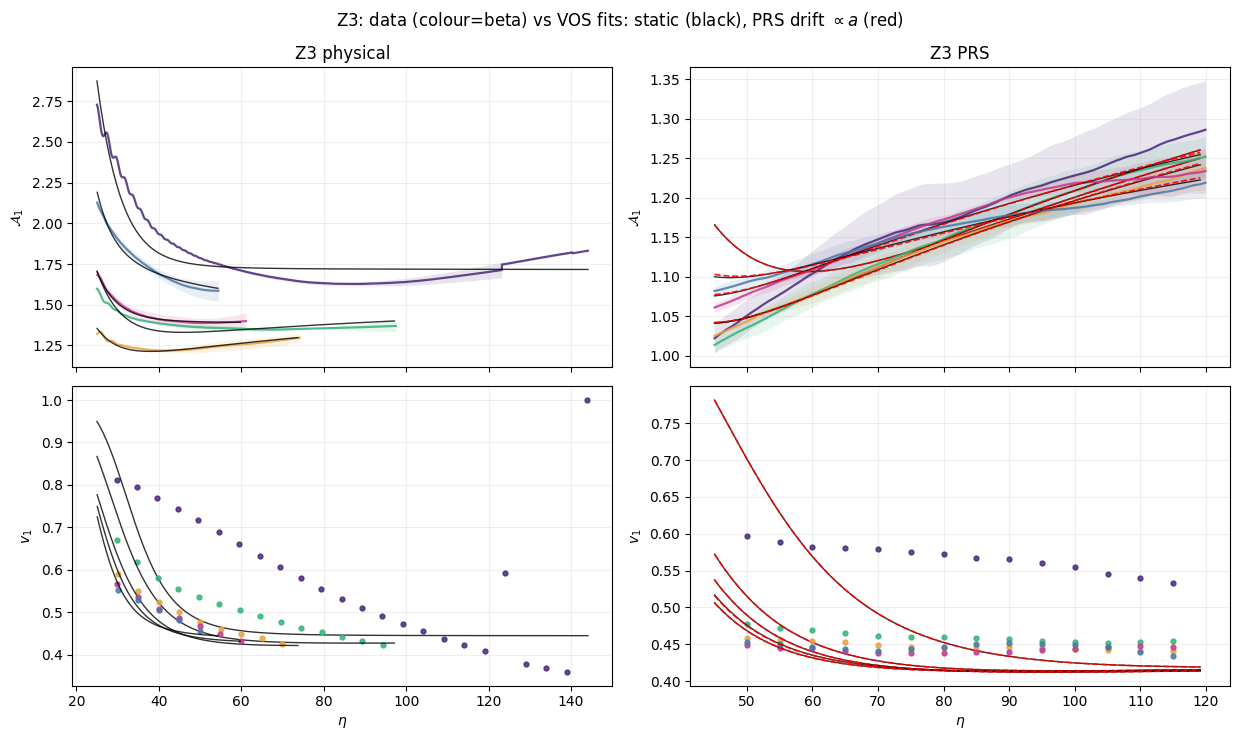

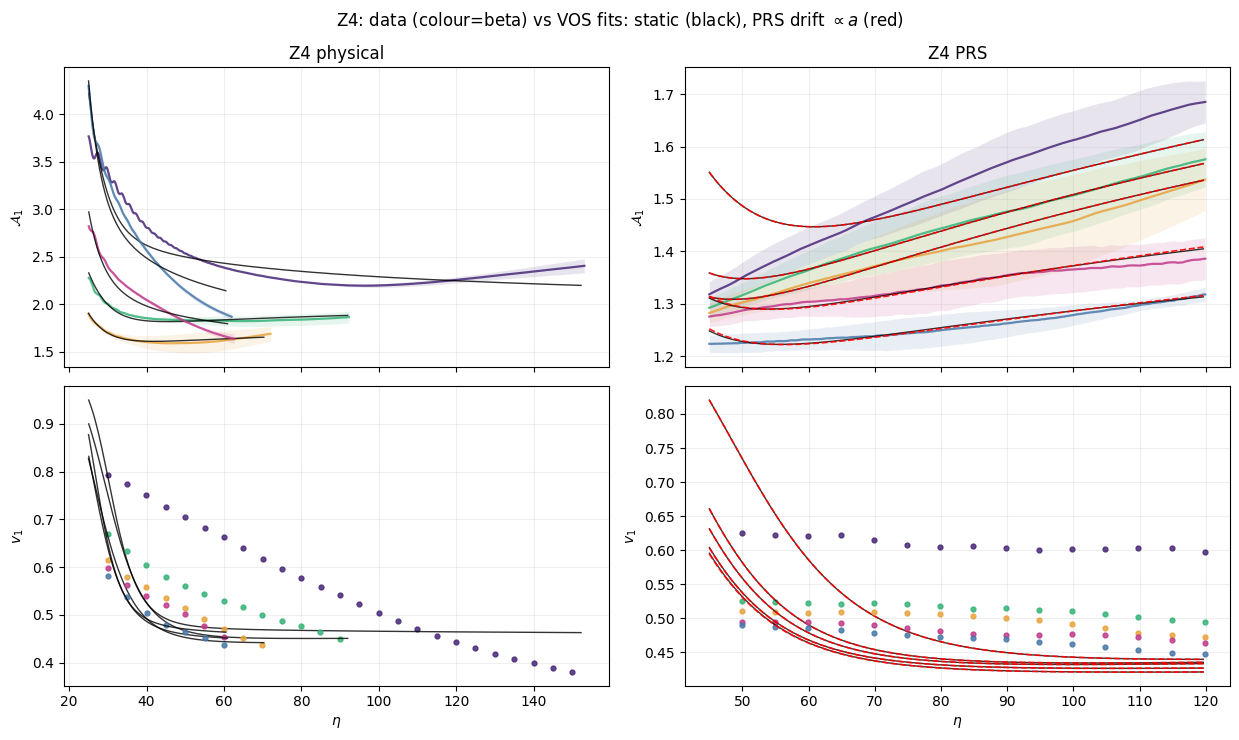

In [6]:
def fit_curves(d, f):
    # evaluate the fitted model on a dense eta grid inside the window (species 1)
    tg = f['tg']
    k = sorted(tg)[0]
    eta = np.linspace(tg[k]['etaA'][0], tg[k]['etaA'][-1], 300)
    tgd = {kk: dict(tA=t_of_eta(d, eta), logA=np.zeros_like(eta), sLogA=np.ones_like(eta),
                    tV=t_of_eta(d, eta), v=np.zeros_like(eta), sv=np.ones_like(eta),
                    etaA=eta, etaV=eta) for kk in tg}
    mod = model_eval(f['theta'], d, tgd, f['variant'])
    return eta, np.exp(mod[k]['logA']), mod[k]['v']

for m in SPEC:
    fig, axes = plt.subplots(2, 2, figsize=(12.5, 7.5), sharex='col')
    for e, col in (('phys', 0), ('prs', 1)):
        axA, axV = axes[0, col], axes[1, col]
        for b in BETAS:
            d = DATA[m][b][e]
            if d is None or (m, b, e, 'static') not in FITS:
                continue
            sp = d['species'][1]
            mA = np.isfinite(sp['A']) & (sp['etaA'] >= d['eta_lo']) & (sp['etaA'] <= d['eta_hi'])
            axA.plot(sp['etaA'][mA], sp['A'][mA], color=BCOL[b], lw=1.6, alpha=0.85)
            axA.fill_between(sp['etaA'][mA], (sp['A'] - sp['sA'])[mA], (sp['A'] + sp['sA'])[mA],
                             color=BCOL[b], alpha=0.12, lw=0)
            mV = np.isfinite(sp['v']) & (sp['etaV'] >= d['eta_lo']) & (sp['etaV'] <= d['eta_hi'])
            axV.plot(sp['etaV'][mV], sp['v'][mV], 'o', color=BCOL[b], ms=3.5, alpha=0.85)
            eta, Afit, vfit = fit_curves(d, FITS[(m, b, e, 'static')])
            axA.plot(eta, Afit, 'k-', lw=1.0, alpha=0.8)
            axV.plot(eta, vfit, 'k-', lw=1.0, alpha=0.8)
            if e == 'prs' and (m, b, e, 'drift') in FITS:
                eta, Afit, vfit = fit_curves(d, FITS[(m, b, e, 'drift')])
                axA.plot(eta, Afit, 'r--', lw=1.2, alpha=0.9)
                axV.plot(eta, vfit, 'r--', lw=1.2, alpha=0.9)
        axA.set_title('%s %s' % (m, {'phys': 'physical', 'prs': 'PRS'}[e]), fontsize=12)
        axA.set_ylabel(r'$\mathcal{A}_1$'); axV.set_ylabel(r'$v_1$')
        axV.set_xlabel(r'$\eta$')
        for ax in (axA, axV):
            ax.grid(alpha=0.2)
    fig.suptitle('%s: data (colour=beta) vs VOS fits: static (black), PRS drift $\\propto a$ (red)' % m)
    fig.tight_layout()
    plt.show()

## Stage-1 verdict figures: $\hat p(\beta)$ and $\chi^2_{\rm red}$ static vs drift

Prediction (notes §9): $\hat p \approx 0$ physical, $\hat p \approx 1$ PRS.
**Outcome: unresolved by wall observables** — $\hat p$ points sit at the fit bounds with
giant error bars (left fig), and the static/drift χ² curves lie on top of each other
(right fig). Kept as the honest record of *why* stage 2 was needed; the third printed
block, $\alpha_J^{\rm phys}(\beta)$, is the piece of stage 1 that IS a deliverable
(note its non-monotonicity in β — peak near β⋆ — vs the monotone-saturating ansatz
Eq. (alphaJ-form) of `vos_zn_section.tex`).

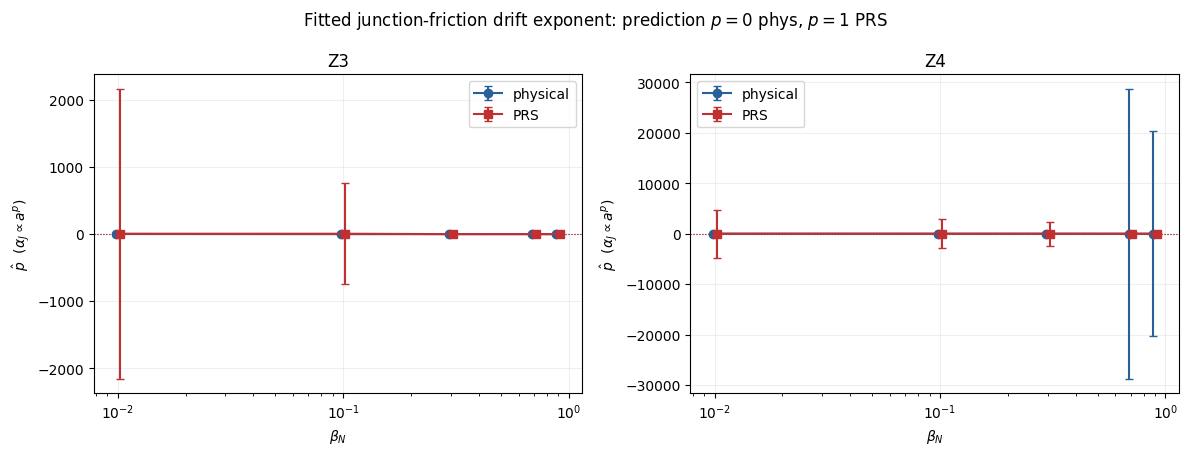

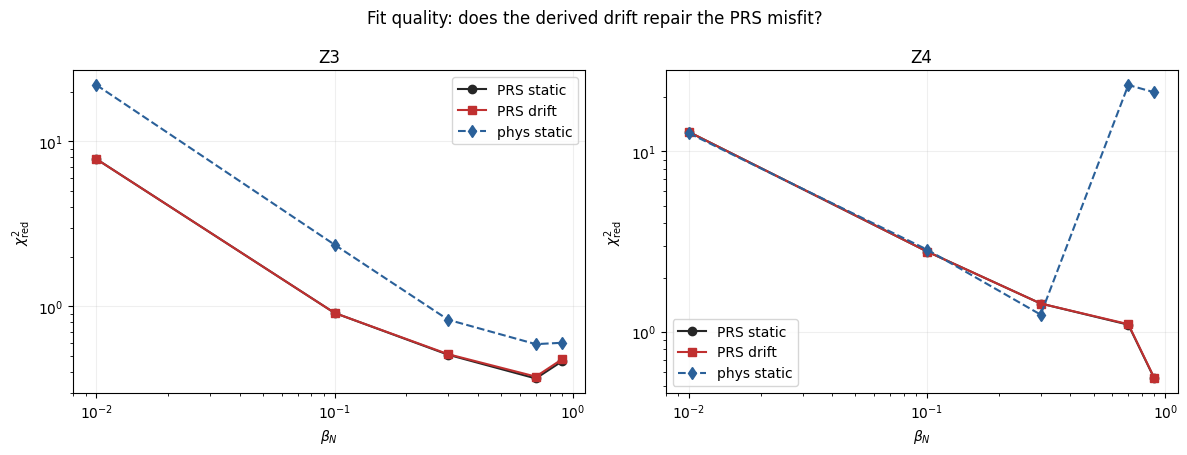

alpha_J^phys(beta) (static fits):
  Z3  beta=0.01  alpha_J =   1.285   chi2red =  21.97
  Z3  beta=0.1   alpha_J =   1.475   chi2red =   2.36
  Z3  beta=0.3   alpha_J =   2.171   chi2red =   0.83
  Z3  beta=0.7   alpha_J =   0.597   chi2red =   0.59
  Z3  beta=0.9   alpha_J =   0.253   chi2red =   0.60
  Z4  beta=0.01  alpha_J =   0.417   chi2red =  12.62
  Z4  beta=0.1   alpha_J =   0.966   chi2red =   2.86
  Z4  beta=0.3   alpha_J =   0.724   chi2red =   1.24
  Z4  beta=0.7   alpha_J =   0.000   chi2red =  23.34
  Z4  beta=0.9   alpha_J =   0.000   chi2red =  21.27


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
for i, m in enumerate(SPEC):
    ax = axes[i]
    for e, mk, off in (('phys', 'o', -0.02), ('prs', 's', 0.02)):
        xs, ys, es = [], [], []
        for b in BETAS:
            f = FITS.get((m, b, e, 'freeP'))
            if f and 'p' in f:
                xs.append(b * (1 + off)); ys.append(f['p']); es.append(f.get('p_err', np.nan))
        ax.errorbar(xs, ys, yerr=es, fmt=mk + '-', capsize=3,
                    label={'phys': 'physical', 'prs': 'PRS'}[e],
                    color={'phys': '#2A6099', 'prs': '#C03030'}[e])
    ax.axhline(0, color='0.4', lw=0.8, ls=':')
    ax.axhline(1, color='#C03030', lw=0.8, ls=':')
    ax.set_xscale('log'); ax.set_xlabel(r'$\beta_N$'); ax.set_ylabel(r'$\hat p$  ($\alpha_J \propto a^p$)')
    ax.set_title(m); ax.legend(); ax.grid(alpha=0.2)
fig.suptitle(r'Fitted junction-friction drift exponent: prediction $p{=}0$ phys, $p{=}1$ PRS')
fig.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
for i, m in enumerate(SPEC):
    ax = axes[i]
    for var, mk, c in (('static', 'o', '0.15'), ('drift', 's', '#C03030')):
        xs, ys = [], []
        for b in BETAS:
            f = FITS.get((m, b, 'prs', var))
            if f:
                xs.append(b); ys.append(f['chi2red'])
        ax.plot(xs, ys, mk + '-', color=c, label='PRS ' + var)
    xs = [b for b in BETAS if (m, b, 'phys', 'static') in FITS]
    ys = [FITS[(m, b, 'phys', 'static')]['chi2red'] for b in xs]
    ax.plot(xs, ys, 'd--', color='#2A6099', label='phys static')
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel(r'$\beta_N$'); ax.set_ylabel(r'$\chi^2_{\rm red}$')
    ax.set_title(m); ax.legend(); ax.grid(alpha=0.2)
fig.suptitle('Fit quality: does the derived drift repair the PRS misfit?')
fig.tight_layout(); plt.show()

print('alpha_J^phys(beta) (static fits):')
for m in SPEC:
    for b in BETAS:
        f = FITS.get((m, b, 'phys', 'static'))
        if f:
            print('  %-3s beta=%-5s alpha_J = %7.3f   chi2red = %6.2f' % (m, b, f['aJ0'], f['chi2red']))

## Stage-1 caveats (carry these into any paper figure)

1. **3 seeds** → seed-std error bands are soft; χ²_red is for variant comparison, not absolute
   goodness-of-fit.
2. **Radiation back-reaction is a second, distinct misfit channel** (PRS over-damps free modes
   as $a^{-3/2}$; the Goldstone is light at small β) — misfit trends at β = 0.01 are *not*
   junction signal. This is why β = 0.01 stays out of headline plots.
3. **Z₄ above β⋆:** the shared-$d_N$ two-species model misfits the *physical* data
   (χ² ≈ 21–23) — the extracted α_J = 0 there is a symptom of model inadequacy, not a
   measurement. Candidate fixes: per-species α_J or momentum parameter, junction-mediated
   coupling beyond the e-term. (PRS fits fine — deceptive; see READ-FIRST finding 5.)
4. **Phys windows shorten as β grows** (resolution cut a_max ∝ DADJ/β-ish): β = 0.9 has only
   ~5–7 velocity points.
5. The Z₂ constants (d₂, r, q, b, k₀) are imported from the literature unchanged; any
   systematic error in them is absorbed into α_J. Tension ratios / junction geometry do not
   enter the single-C VOS (notes §3.3).

## Stage 2a — the velocity 'dressing' law (PRS → physical translation) ✅ RESULT

**Motivation (DP):** the wall *scaling* fits decently under PRS but the *velocity* doesn't —
if the velocity misfit is a clean function of the scale factor, that's a usable prescription:
"fit PRS this way, multiply by a power of $a$ to quote physical."

**Method.** Two independent estimates of the residual power:
1. **VOS-referenced** ($\hat q$): take each `static` wall fit as the reference shape, regress
   $\ln(v_{\rm data}/v_{\rm VOS})$ on $\ln a$ over the fit window (weighted by seed σ; the
   quoted ±err is the regression slope error). Uses ALL of each run's window; the VOS absorbs
   the trivial $3Hv$ relaxation so $\hat q$ isolates the anomalous drift.
2. **Model-free** ($q_{\rm mf}$, grey diamonds): direct ratio $v_{\rm PRS}(\eta)/v_{\rm phys}(\eta)$
   in the overlap window (η ≥ 45, both resolved), no VOS involved. Larger than $\hat q$ because
   it convolves both runs' transients and windows — treat as an envelope, quote $\hat q$.

**Result (2026-07-03):** $\hat q_{\rm phys} \approx 0.08$–$0.13 \pm 0.1$ → consistent with zero
(physical velocities are VOS-shaped). $\hat q_{\rm PRS} \approx 0.12$–$0.23 \pm 0.03$–$0.05$ →
**nonzero, stable across β = 0.1–0.9 and across Z₃/Z₄**; β = 0.01 gives ≈ 0.50 (radiation
corner, separate physics). $q_{\rm mf} \approx 0.3$–$0.5$.

**Prescription:** PRS wall velocities, *after* the established ×$a^2$ weight correction, still
carry a spurious $a^{\hat q}$ growth relative to the physical/VOS velocity — divide it out
(calibrated here against physical anchors). **Open theory target:** derive $\hat q$ — candidate
mechanisms: persistent sub-horizon corrugations under PRS (the KE/V mask picks up wiggle KE
that physical evolution redshifts away; cf. the PRS-creep mechanism memo) and/or radiation
back-reaction (notes §5, D5). A derivation would promote this from calibration to law.

mod  beta            q_phys            q_prs q_modelfree
Z3   0.01      0.147+-0.108     0.495+-0.069      0.513
Z3   0.1       0.078+-0.062     0.161+-0.035      0.297
Z3   0.3       0.094+-0.070     0.123+-0.030      0.298
Z3   0.7       0.109+-0.088     0.123+-0.017      0.356
Z3   0.9       0.122+-0.115     0.135+-0.026          -
Z4   0.01     -0.212+-0.065     0.517+-0.065      0.471
Z4   0.1       0.082+-0.078     0.226+-0.053      0.326
Z4   0.3       0.114+-0.097     0.206+-0.053      0.472
Z4   0.7       0.129+-0.112     0.158+-0.041      0.502
Z4   0.9       0.068+-0.092     0.127+-0.041      0.290


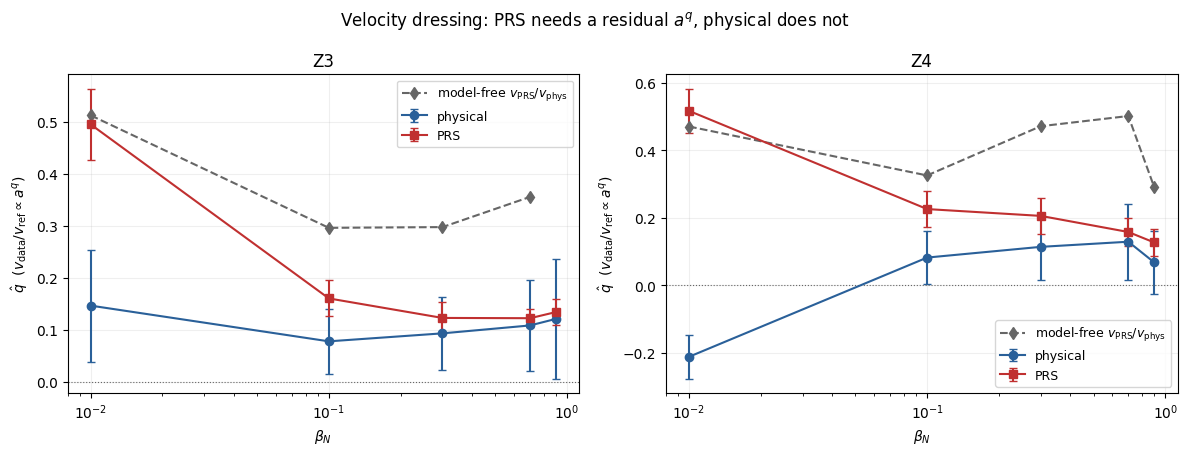

In [8]:
QROWS = {}
for (m, b, e, var), f in sorted(FITS.items()):
    if var != 'static':
        continue
    d = DATA[m][b][e]
    tg = f['tg']
    mod = model_eval(f['theta'], d, tg, 'static')
    k = sorted(tg)[0]
    a_v = d['a_of'](tg[k]['etaV'])
    ratio = tg[k]['v'] / np.clip(mod[k]['v'], 1e-6, None)
    ok = np.isfinite(ratio) & (ratio > 0)
    if ok.sum() < 4:
        continue
    w = (tg[k]['v'][ok] / tg[k]['sv'][ok])
    (q, c0), cov = np.polyfit(np.log(a_v[ok]), np.log(ratio[ok]), 1, w=w, cov=True)
    QROWS[(m, b, e)] = (q, float(np.sqrt(cov[0, 0])))

QMF = {}
for m in SPEC:
    for b in BETAS:
        dp, dr = DATA[m][b]['phys'], DATA[m][b]['prs']
        if dp is None or dr is None:
            continue
        sp, sr = dp['species'][1], dr['species'][1]
        okp = np.isfinite(sp['v'])
        lo, hi = 45.0, min(dp['eta_hi'], sp['etaV'][okp][-1] if okp.any() else -1, sr['etaV'][-1])
        if hi <= lo + 10:
            continue
        grid = np.linspace(lo, hi, 25)
        vp = np.interp(grid, sp['etaV'], sp['v'])
        vr = np.interp(grid, sr['etaV'], sr['v'])
        ok = np.isfinite(vp) & np.isfinite(vr) & (vp > 0) & (vr > 0)
        if ok.sum() < 5:
            continue
        QMF[(m, b)] = float(np.polyfit(np.log(dr['a_of'](grid[ok])), np.log(vr[ok] / vp[ok]), 1)[0])

print('%-4s %-5s %16s %16s %10s' % ('mod', 'beta', 'q_phys', 'q_prs', 'q_modelfree'))
for m in SPEC:
    for b in BETAS:
        qp = QROWS.get((m, b, 'phys')); qr = QROWS.get((m, b, 'prs')); qm = QMF.get((m, b))
        fmt = lambda x: ('%6.3f+-%5.3f' % x) if x else '        -'
        print('%-4s %-5s %16s %16s %10s' % (m, b, fmt(qp), fmt(qr),
                                            ('%7.3f' % qm) if qm is not None else '   -'))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
for i, m in enumerate(SPEC):
    ax = axes[i]
    for e, c, mk in (('phys', '#2A6099', 'o'), ('prs', '#C03030', 's')):
        xs = [b for b in BETAS if (m, b, e) in QROWS]
        ys = [QROWS[(m, b, e)][0] for b in xs]
        es = [QROWS[(m, b, e)][1] for b in xs]
        ax.errorbar(xs, ys, yerr=es, fmt=mk + '-', capsize=3, color=c,
                    label={'phys': 'physical', 'prs': 'PRS'}[e])
    xs = [b for b in BETAS if (m, b) in QMF]
    ax.plot(xs, [QMF[(m, b)] for b in xs], 'd--', color='0.4', label=r'model-free $v_{\rm PRS}/v_{\rm phys}$')
    ax.axhline(0, color='0.4', lw=0.8, ls=':')
    ax.set_xscale('log'); ax.set_xlabel(r'$\beta_N$')
    ax.set_ylabel(r'$\hat q$  ($v_{\rm data}/v_{\rm ref} \propto a^{q}$)')
    ax.set_title(m); ax.legend(fontsize=9); ax.grid(alpha=0.2)
fig.suptitle('Velocity dressing: PRS needs a residual $a^{q}$, physical does not')
fig.tight_layout(); plt.show()

## Stage 2b — junction-string sector: measuring the damping index $n$ · ❌ VERDICT: NOT IDENTIFIABLE (kept as methodology + honest record)

**Model.** One-scale string sector for the junction lines, independent of the wall fit
($\rho_L = 1/\ell_J^2$ ⇒ $\xi = \mathrm{norm}\cdot(t/\ell_J)^2$; the norm absorbs the
`Jstr_len` counter calibration and is COMMON to both evolutions):

$$\dot\ell_J = (1+v_J^2)H\ell_J + c_J v_J, \qquad
\dot v_J = (1-v_J^2)\left[\frac{k_J}{\ell_J} - n\,H\,v_J\right]$$

**Derived prediction (F₂, notes §9.2–9.3): $n{=}2$ physical, $n{=}3$ PRS** — junction strings
over-damped by one power of $a$ in any width-fixed wall-exact scheme; over-damped → slower →
less chopping → ξ fails to plateau (the measured PRS behaviour, slides 33/56).

**Test design.** Joint phys+PRS fit per (model, β) with **common micro-parameters**
$(k_J, c_J, \mathrm{norm})$ and per-evolution $v_{J0}$ ($\ell_{J0}$ is TIED to the first ξ
point given the norm — it was exactly degenerate with the norm when free). Variants:
`derived` $n=(2,3)$ · `naive` $n=(2,2)$ swap test · `freeN` both $n$ free
(would-be headline $\hat n_{\rm prs} - \hat n_{\rm phys} \approx 1$).
Physical ξ window uses cells/core ≥ CORE_MIN (cores, not walls, set the ξ resolution limit).
$v_J$ is latent — no junction-velocity observable is fitted.

**Verdict (2026-07-03): the test FAILS to discriminate.** χ²(2,3) ≈ χ²(2,2) in every row
(both fit the PRS rise equally well) and `freeN` returns $\hat n$ with errors ±5–25, railing
at the bounds. Root cause: the ξ(η) trajectories are near-featureless power laws, and the
remaining freedoms (norm, $v_{J0}$, $k_J$, $c_J$) can trade off against $n$ — a one-scale
model with a free momentum parameter can produce the same slow rise with $n{=}2$ as with
$n{=}3$. Tying $\ell_{J0}$ (done) was not enough. Z₄ above β⋆: the joint common-micro fit
fails outright in ALL modes (χ² ≈ 4–9) — phys and PRS ξ shapes there are incompatible with
any common micro-parameters (same lesson as the wall sector: the model, not the exponent).

**Paths to an actual $n$-measurement:**
1. **Junction-velocity observable** — the `velA06` deep-potential mask (V > 0.6·Vmax is
   core-biased) is already in the data files; fitting $v_J$ would break the $v_{J0}/k_J/n$
   degeneracy. Untried.
2. **The boosted-junction rig** (notes §4.2(2)): measures $\gamma v(a)$ of a single junction
   string directly — no network model in the loop. Decisive; also tests the blade caveat on F₂.

In [9]:
def rhsJ(t, y, kJ, cJ, n):
    ell = max(float(y[0]), 1e-12)
    v = min(max(float(y[1]), 1e-8), 0.999)
    H = 0.5 / t
    return [(1 + v**2) * H * ell + cJ * v,
            (1 - v**2) * (kJ / ell - n * H * v)]

def xi_targets(d):
    x = d['xi']
    if x['xi'] is None:
        return None
    hi = d['eta_hi_core'] if d['evo'] == 'phys' else np.inf
    mk = (np.isfinite(x['xi']) & (x['xi'] > 0) & (x['eta'] >= d['eta_lo']) & (x['eta'] <= hi))
    if mk.sum() < 5:
        return None
    sig = np.sqrt((x['sxi'][mk] / x['xi'][mk])**2 + SIG_XI_FLOOR**2)
    return dict(t=t_of_eta(d, x['eta'][mk]), logxi=np.log(x['xi'][mk]), sig=sig, eta=x['eta'][mk])

EVS = ('phys', 'prs')

def fitJ(m, b, mode):
    tgs = {}
    for e in EVS:
        d = DATA[m][b][e]
        if d is not None:
            tt = xi_targets(d)
            if tt is not None:
                tgs[e] = tt
    if len(tgs) < 2:
        return None

    def unpack(theta):
        # ell_J0 is tied to the first xi point given the norm (degenerate otherwise):
        # xi0 = norm (t0/ell0)^2  =>  ell0 = t0 exp[(lnn - logxi0)/2]
        kJ, cJ, lnn = 10.0**theta[0], theta[1], theta[2]
        ics = {e: (tgs[e]['t'][0] * np.exp(0.5 * (lnn - tgs[e]['logxi'][0])), theta[3 + j])
               for j, e in enumerate(EVS)}
        if mode == 'freeN':
            n = {'phys': theta[5], 'prs': theta[6]}
        elif mode == 'naive':
            n = {'phys': 2.0, 'prs': 2.0}
        else:
            n = {'phys': 2.0, 'prs': 3.0}
        return kJ, cJ, lnn, ics, n

    ntot = sum(len(tgs[e]['logxi']) for e in tgs)

    def rr(theta):
        kJ, cJ, lnn, ics, n = unpack(theta)
        out = []
        for e in EVS:
            tg = tgs[e]
            sol = solve_ivp(rhsJ, (0.999 * tg['t'][0], 1.001 * tg['t'][-1]), list(ics[e]),
                            args=(kJ, cJ, n[e]), dense_output=True, rtol=1e-8, atol=1e-10)
            if not sol.success:
                return np.full(ntot, 1e3)
            ell = np.clip(sol.sol(tg['t'])[0], 1e-12, None)
            out.append((tg['logxi'] - (lnn + 2.0 * np.log(tg['t'] / ell))) / tg['sig'])
        return np.concatenate(out)

    best = None
    for kJt in (0.1, 0.5, 1.5):
        for v0 in (0.2, 0.5):
            th0 = [np.log10(kJt), 0.2, 0.0]
            lo = [-3.0, 0.0, -14.0]
            hi = [1.0, 2.0, 14.0]
            for e in EVS:
                th0 += [v0]; lo += [0.01]; hi += [0.95]
            if mode == 'freeN':
                th0 += [2.0, 3.0]; lo += [0.5, 0.5]; hi += [6.0, 6.0]
            with warnings.catch_warnings():
                warnings.simplefilter('ignore')
                try:
                    sol = least_squares(rr, th0, bounds=(lo, hi), args=(),
                                        x_scale='jac', max_nfev=600)
                except Exception:
                    continue
            if best is None or sol.cost < best.cost:
                best = sol
    if best is None:
        return None
    npar = len(best.x)
    out = dict(mode=mode, theta=best.x, tgs=tgs,
               chi2red=2.0 * best.cost / max(ntot - npar, 1),
               kJ=10.0**best.x[0], cJ=best.x[1])
    if mode == 'freeN':
        out['n_phys'], out['n_prs'] = best.x[5], best.x[6]
        try:
            J = best.jac
            cov = np.linalg.inv(J.T @ J) * out['chi2red']
            out['n_phys_err'] = float(np.sqrt(max(cov[5, 5], 0)))
            out['n_prs_err'] = float(np.sqrt(max(cov[6, 6], 0)))
        except Exception:
            out['n_phys_err'] = out['n_prs_err'] = np.nan
    return out

JFITS = {}
for m in SPEC:
    for b in BETAS:
        for mode in ('derived', 'naive', 'freeN'):
            f = fitJ(m, b, mode)
            if f is not None:
                JFITS[(m, b, mode)] = f

print('%-4s %-5s %10s %10s %18s %18s' % ('mod', 'beta', 'chi2(2,3)', 'chi2(2,2)', 'n_phys(free)', 'n_prs(free)'))
for m in SPEC:
    for b in BETAS:
        fd = JFITS.get((m, b, 'derived')); fn = JFITS.get((m, b, 'naive')); ff = JFITS.get((m, b, 'freeN'))
        if fd is None:
            continue
        s1 = '%7.2f' % fd['chi2red']
        s2 = ('%7.2f' % fn['chi2red']) if fn else '     -'
        s3 = ('%6.2f+-%5.2f' % (ff['n_phys'], ff['n_phys_err'])) if ff else '        -'
        s4 = ('%6.2f+-%5.2f' % (ff['n_prs'], ff['n_prs_err'])) if ff else '        -'
        print('%-4s %-5s %10s %10s %18s %18s' % (m, b, s1, s2, s3, s4))

mod  beta   chi2(2,3)  chi2(2,2)       n_phys(free)        n_prs(free)
Z3   0.01        0.03       0.02        1.05+- 8.18        0.50+- 7.17
Z3   0.1         0.02       0.02        1.78+-14.06        2.09+-11.96
Z3   0.3         0.03       0.03        4.73+-26.12        6.00+-24.66
Z3   0.7         0.26       0.19        4.60+- 5.49        2.54+- 5.59
Z3   0.9         0.09       0.05        6.00+-15.11        4.20+-11.47
Z4   0.01        0.01       0.00        6.00+- 2.69        5.99+- 2.12
Z4   0.1         0.01       0.01        6.00+-11.27        5.17+-10.82
Z4   0.3         0.09       0.05        6.00+-14.30        3.01+-12.99
Z4   0.7         8.91       8.91   6.00+-1182005.57    6.00+-727387.43
Z4   0.9         4.26       4.26   6.00+-1261514.33    6.00+-702840.94


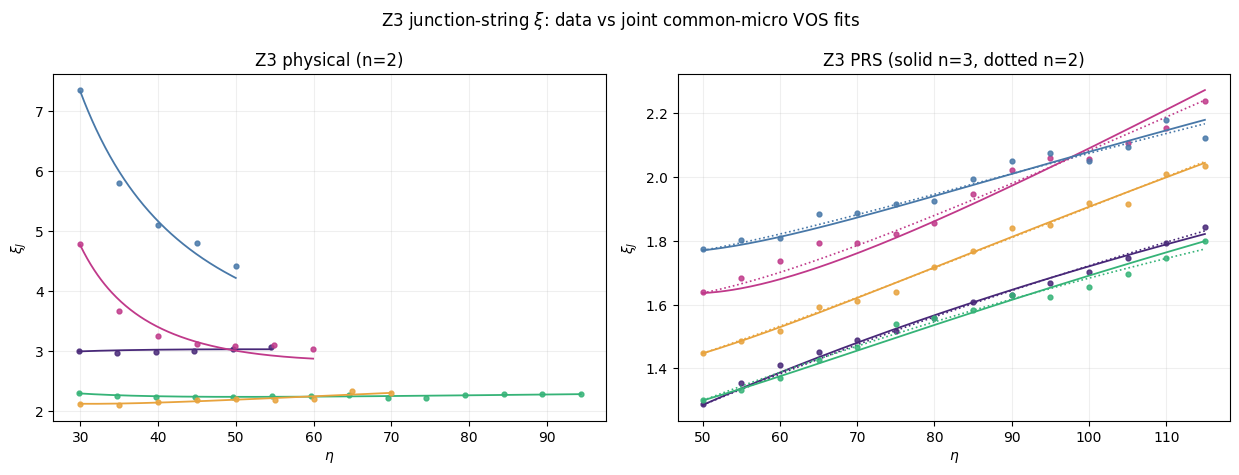

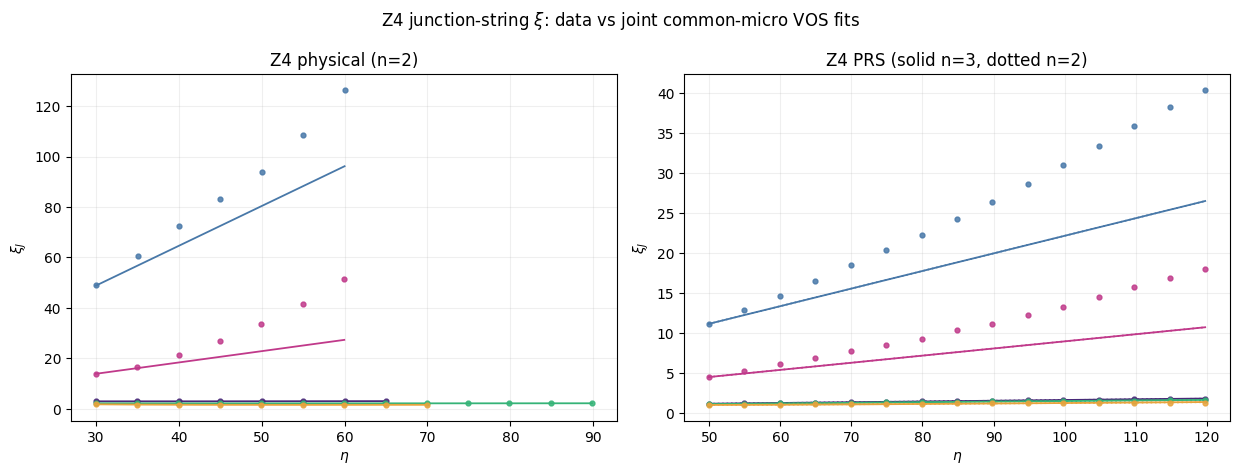

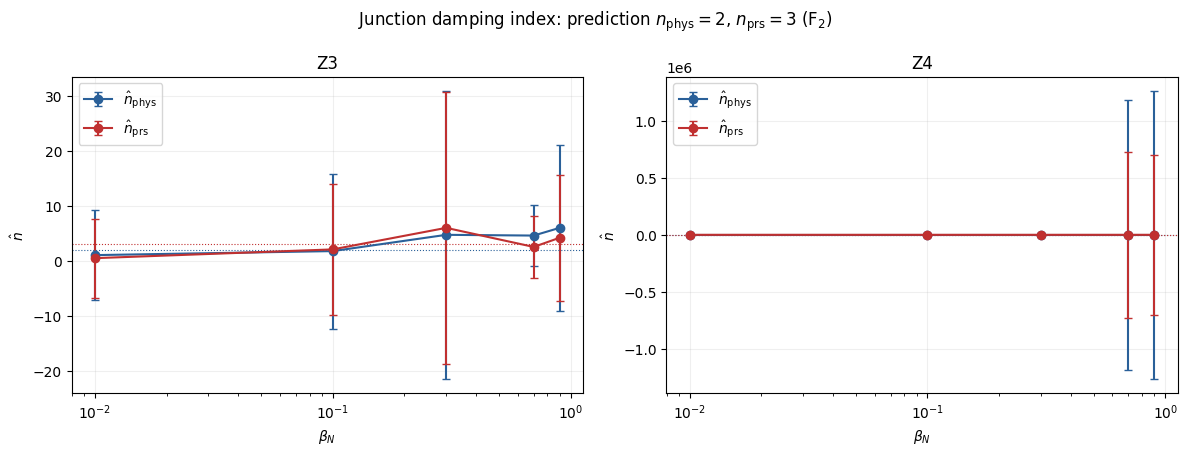

In [10]:
def xi_fit_curve(f, e, d):
    kJ, cJ = f['kJ'], f['cJ']
    lnn = f['theta'][2]
    j = list(EVS).index(e)
    tg0 = f['tgs'][e]
    ic = (tg0['t'][0] * np.exp(0.5 * (lnn - tg0['logxi'][0])), f['theta'][3 + j])
    n = ({'phys': f.get('n_phys', 2.0), 'prs': f.get('n_prs', 3.0)} if f['mode'] == 'freeN'
         else {'phys': 2.0, 'prs': 2.0} if f['mode'] == 'naive'
         else {'phys': 2.0, 'prs': 3.0})[e]
    tg = f['tgs'][e]
    tt = np.linspace(tg['t'][0], tg['t'][-1], 200)
    sol = solve_ivp(rhsJ, (0.999 * tt[0], 1.001 * tt[-1]), list(ic), args=(kJ, cJ, n),
                    dense_output=True, rtol=1e-8, atol=1e-10)
    ell = np.clip(sol.sol(tt)[0], 1e-12, None)
    eta = np.interp(tt, tg['t'], tg['eta'])
    return eta, np.exp(lnn) * (tt / ell)**2

for m in SPEC:
    fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8), sharey=False)
    for e, ax in zip(EVS, axes):
        for b in BETAS:
            d = DATA[m][b][e]
            fd = JFITS.get((m, b, 'derived')); fn = JFITS.get((m, b, 'naive'))
            if d is None or fd is None or e not in fd['tgs']:
                continue
            tg = fd['tgs'][e]
            ax.plot(tg['eta'], np.exp(tg['logxi']), 'o', color=BCOL[b], ms=3.5, alpha=0.85)
            eta, xif = xi_fit_curve(fd, e, d)
            ax.plot(eta, xif, '-', color=BCOL[b], lw=1.3)
            if fn is not None and e == 'prs' and e in fn['tgs']:
                eta, xif = xi_fit_curve(fn, e, d)
                ax.plot(eta, xif, ':', color=BCOL[b], lw=1.2)
        ax.set_title('%s %s' % (m, {'phys': 'physical (n=2)', 'prs': 'PRS (solid n=3, dotted n=2)'}[e]))
        ax.set_xlabel(r'$\eta$'); ax.set_ylabel(r'$\xi_J$'); ax.grid(alpha=0.2)
    fig.suptitle(r'%s junction-string $\xi$: data vs joint common-micro VOS fits' % m)
    fig.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
for i, m in enumerate(SPEC):
    ax = axes[i]
    for key, c, lab in (('n_phys', '#2A6099', r'$\hat n_{\rm phys}$'), ('n_prs', '#C03030', r'$\hat n_{\rm prs}$')):
        xs = [b for b in BETAS if (m, b, 'freeN') in JFITS]
        ys = [JFITS[(m, b, 'freeN')][key] for b in xs]
        es = [JFITS[(m, b, 'freeN')][key + '_err'] for b in xs]
        ax.errorbar(xs, ys, yerr=es, fmt='o-', capsize=3, color=c, label=lab)
    ax.axhline(2, color='#2A6099', lw=0.8, ls=':')
    ax.axhline(3, color='#C03030', lw=0.8, ls=':')
    ax.set_xscale('log'); ax.set_xlabel(r'$\beta_N$'); ax.set_ylabel(r'$\hat n$')
    ax.set_title(m); ax.legend(); ax.grid(alpha=0.2)
fig.suptitle(r'Junction damping index: prediction $n_{\rm phys}{=}2$, $n_{\rm prs}{=}3$ (F$_2$)')
fig.tight_layout(); plt.show()

---
## Final verdict & handoff (end of session 2026-07-03)

**What this notebook delivers:**
1. $\alpha_J^{\rm phys}(\beta)$ — the paper-1 junction-importance curve (stage-1 static fits).
   The **Z₃ curve is solid as-is** (χ² ≤ 2.4 for β ≥ 0.1, non-monotonic with a peak near β⋆).
   The **Z₄ points above β⋆ are NOT measurements** (α_J → 0 rail + χ² ≈ 21–23 = model
   inadequacy) — the two-species ansatz needs fixing before that part of the figure exists.
2. The **velocity dressing law** $\hat q$ (stage 2a) — the one clean, quotable *new* number:
   PRS velocities carry a spurious $\times a^{\hat q}$, $\hat q \approx 0.12$–$0.23$,
   β-stable, both models; physical is consistent with $\hat q = 0$. Prescription-ready.
3. Two **negative results kept deliberately** (they shape what to do next): the wall-sector
   drift exponent $p$ and the junction damping index $n$ are both unidentifiable from
   network trajectories alone — structural degeneracies, not noise.

**Where to go next (agreed):**
- **(a)** Try the `velA06` deep-potential mask as a junction-velocity proxy on the *existing*
  data — if it tracks a distinct, more-damped component under PRS, the $n$-measurement
  (stage 2b) may not need the rig: fitting $v_J$ breaks the $v_{J0}/k_J/n$ degeneracy.
- **(b)** The **boosted-junction rig** (notes §4.2(2)) — now carries two jobs: verify F₂
  (n=2 vs 3 directly, single defect, no network model) AND test the blade caveat
  (the one open item in the D1+D2 audit).
- **(c)** Paper-1 α_J(β) figure: Z₃ ready; Z₄-above-β⋆ needs the two-species model fix
  first (per-species α_J / momentum parameter, or junction-mediated coupling beyond e).

**Companion artefacts:** `beyond_prs_ZN_framework_notes.md` §9 (derivations D1, F₂ +
no-go audit) · `analysis/vos_zn_section.tex` (VOS spec; its α_J ansatz Eq. (alphaJ-form)
is now contradicted by finding 1) · memory `project_beyond_prs_framework`.